In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np

In [2]:
example = glob("*.out")[0]

In [3]:
file_name = example

In [4]:
words = file_name.replace(".out", "").split("_")

In [5]:
map, alg, lookahead = words

ValueError: too many values to unpack (expected 3)

In [3]:
dat = []
for file_name in glob("random*.out"):
    try:
        map, alg, lookahead, rep = file_name.replace(".out", "").split("_")
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
    dat.append((map, alg, lookahead, rep, expansions, cost))

In [4]:
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead","rep", "expansions", "cost"])
data.cost = np.nanmin([data.cost, 10000*np.ones(len(data.cost))], axis = 0)

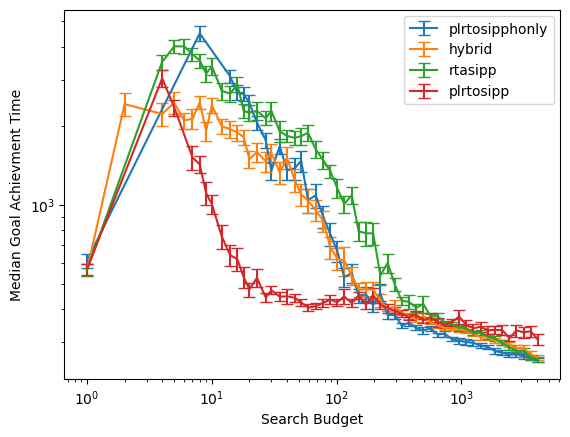

In [6]:
plt.figure()
for alg in set(data.Algorithm):
    d = data.loc[data.Algorithm == alg]
    d = d.sort_values("Lookahead")
    x = []
    y = []
    yerr = []
    for lookahead in set(d.Lookahead):
        if (d.loc[d.Lookahead== lookahead].cost < 10000).all():
            x.append(lookahead)
            y.append(d.loc[d.Lookahead== lookahead].cost.mean())
            yerr.append(np.std(d.loc[d.Lookahead== lookahead].cost)/np.sqrt(len(d.loc[d.Lookahead== lookahead].cost)))
    x = np.asarray(x)
    y = np.asarray(y)
    yerr = np.asarray(yerr)
    ind = np.argsort(x)
    plt.errorbar(x[ind], y[ind],yerr[ind].T, linestyle = None, capsize = 
                 4, label = alg)
plt.legend()
plt.loglog()
plt.ylabel("Median Goal Achievment Time")
plt.xlabel("Search Budget")
plt.savefig("example.png")

In [7]:
data[data.Lookahead==3]

,Map,Algorithm,Lookahead,rep,expansions,cost
147,random512-25-0,rtasipp,3,26,8874.0,2972.38
163,random512-25-0,plrtosipp,3,21,4110.0,1380.97
164,random512-25-0,plrtosipp,3,16,7308.0,2452.28
187,random512-25-0,hybrid,3,10,8646.0,2905.42
284,random512-25-0,rtasipp,3,31,19086.0,6634.98
...,...,...,...,...,...,...
6568,random512-25-0,plrtosipphonly,3,5,20832.0,7307.96
6770,random512-25-0,plrtosipp,3,30,13380.0,4541.60
6981,random512-25-0,plrtosipphonly,3,30,19482.0,7118.19
6983,random512-25-0,rtasipp,3,12,17922.0,6269.98


In [27]:
set(data.Lookahead)

{1, 3, 5, 9, 16, 27, 48, 84, 147, 256, 445, 776, 1351, 2352, 4096}